In [ ]:
!pip install torchvision4ad
!pip install torch-intermediate-layer-getter

In [ ]:
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.utils.data
import torchvision.utils as vutils
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision4ad.datasets import MVTecAD
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torch_intermediate_layer_getter import IntermediateLayerGetter
from torchvision.utils import save_image, make_grid
from torch.autograd import Function
from torch.utils.data import DataLoader
import time
# Set random seed for reproducibility
manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  999


In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
import os

In [ ]:
mvtec_folder='/content/drive/MyDrive/mvtec_ad'

In [ ]:
os.listdir(mvtec_folder)

['grid.tar.xz', 'grid']

In [ ]:
#for comparison: downscaling from a 128*128 image to a latent vector of size 64 using a pytorch convolutional neural network.
import torch
import torch.nn as nn

class ImageToLatent(nn.Module): #stretches the image, and downscales it to 64 by 1 vector
    def __init__(self):
        super(ImageToLatent, self).__init__()
        self.linear = nn.Linear(128 * 128, 64)

    def forward(self, x):
        # Reshape the image to a vector
        x = x.view(x.size(0), -1)  # Flatten the image
        # Pass through the linear layer
        latent_vector = self.linear(x)
        return latent_vector



class CNNEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.relu2 = nn.ReLU()
        # ... add more convolutional layers as needed
        self.fc = nn.Linear(64 * 32 * 32, latent_dim) # Adjust input size based on conv layers

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        # ... pass through other conv layers
        x = x.view(x.size(0), -1)  # Flatten for the fully connected layer
        x = self.fc(x)
        return x

# Example Usage
cnn_encoder = CNNEncoder()
image = torch.randn(1, 1, 128, 128)
latent_vector_cnn = cnn_encoder(image)
print("Latent vector shape from CNN:", latent_vector_cnn.shape)

Latent vector shape from CNN: torch.Size([1, 64])


In [ ]:
#print number of cnn_encoder parameters
print(sum(p.numel() for p in cnn_encoder.parameters()))

4213184


In [ ]:
from torch.utils.data import Subset

# Custom dataset class to load and preprocess MVTec-AD grid images
class GridDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, image_count=None):
        full_dataset = MVTecAD(root_dir, 'grid', train=False, download=True)

        # Trim the dataset to only the specified number of images using Subset
        if image_count is not None:
            indices = list(range(min(image_count, len(full_dataset))))
            self.dataset = Subset(full_dataset, indices)
        else:
            self.dataset = full_dataset

        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.Grayscale(),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        img = self.transform(img)
        return img

# Function to extract patches from an image
def extract_patches(image, patch_size=128):
    patches = [
        image[:, i:i+patch_size, j:j+patch_size]
        for i in range(patch_size, image.shape[1]-patch_size, patch_size)
        for j in range(patch_size, image.shape[2]-patch_size, patch_size)
    ]
    return patches

# Main process
def process_grid_images(image_count=None):
    # Load the dataset with specified image_count
    dataset = GridDataset(root_dir=mvtec_folder, image_count=image_count)
    dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

    patches_final = []
    #here the for loop is un-necessary;
    for idx, img in enumerate(dataloader):
        assert img.shape == (len(dataset), 1, 512, 512), f"Image {idx} has incorrect dimensions: {img.shape}"
        print(idx)
        # Extract patches
        for i in range(len(dataset)):
            image_patches = extract_patches(img[i])
            patches_final.append(image_patches)

            print(f"Processed image {idx}: {len(image_patches)} patches extracted")

    return patches_final, dataloader, dataset

In [ ]:
patches_final,dataloader,dataset=process_grid_images()

0
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 patches extracted
Processed image 0: 4 pa

In [ ]:
len(patches_final), len(dataloader), len(dataset)

(78, 1, 78)

In [ ]:
grid_test_dir=mvtec_folder+'/grid/test'
transforms_original_test=transforms.Compose([transforms.ToTensor()])
original_dataset=ImageFolder(grid_test_dir,transform=transforms_original_test)
original_dataloader=DataLoader(original_dataset,batch_size=len(original_dataset),shuffle=False)
patches_final[0][0].shape

torch.Size([1, 128, 128])

In [ ]:
type(patches_final[0])

# initial preparation of the test dataset to be used in the second training phase
test_dataset=[]
for i in range(len(patches_final)):
  for j in range(len(patches_final[i])):
    test_dataset.append(patches_final[i][j])
test_dataset=torch.stack(test_dataset)
class GridDataset_patches(torch.utils.data.Dataset):
  def __init__(self,dataset):
        self.dataset = dataset


  def __len__(self):
        return len(self.dataset)

  def __getitem__(self, idx):
        img = self.dataset[idx]
        return img
test_dataset=GridDataset_patches(test_dataset)
test_dataloader=DataLoader(test_dataset,batch_size=1,shuffle=False)
transform_ground_truth=transforms.Compose([transforms.Resize((512,512)),transforms.ToTensor()])
import os
os.listdir(mvtec_folder+'/grid/test')

['bent_rot',
 'glue_rot',
 'metal_contamination_rot',
 'thread_rot',
 'broken_rot',
 'good_rot']

In [ ]:
# Number of workers for dataloader
workers = 4
# Spatial size of training images. All images will be resized to this
# size using a transformer.
image_size = 128
# Number of channels in the training images. For color images this is 3
nc = 1
# Size of z latent vector (i.e. size of generator input)
nz = 64
# Size of feature maps in generator
ngf = 64
# Size of feature maps in discriminator
ndf = 64
# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1
beta1=0.5

In [ ]:
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
device

device(type='cpu')

In [ ]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
seed_size=int(image_size/16)
seed=int(ngf*8*seed_size*seed_size)
seed, seed_size

(32768, 8)

In [ ]:
class Generator(nn.Module): #modify this; first layer is linear , and then reshape (check if batchnorm and relu were used after this layer)
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a linear layer
            nn.Linear(nz,seed,bias=True),
            nn.Unflatten(1,(ngf*8,seed_size,seed_size)),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),
            # state size. ``(ngf*8) x 4 x 4``
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 5, 2, 2, 1, bias=True),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. ``(ngf*4) x 8 x 8``
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 5, 2, 2, 1, bias=True),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. ``(ngf*2) x 16 x 16``
            nn.ConvTranspose2d( ngf * 2, ngf, 5, 2, 2, 1, bias=True),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf,nc,5,2,2,1,bias=True),
            nn.Tanh()
            # state size. ``(nc) x 64 x 64``
        )

    def forward(self, input):
        return self.main(input)

In [ ]:
# Create the generator
netG = Generator(ngpu).to(device)
# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))
# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)
# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): Linear(in_features=64, out_features=32768, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(512, 8, 8))
    (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): ConvTranspose2d(64, 1, kernel_size=(5,

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is ``(nc) x 64 x 64``
            nn.Conv2d(nc, ndf, 5, 2, 2, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf) x 32 x 32``
            nn.Conv2d(ndf, ndf * 2, 5, 2, 2, bias=True),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*2) x 16 x 16``
            nn.Conv2d(ndf * 2, ndf * 4, 5, 2, 2, bias=True),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*4) x 8 x 8``
            nn.Conv2d(ndf * 4, ndf * 8, 5, 2, 2, bias=True),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*8) x 4 x 4``
            nn.Flatten(start_dim=1),
            nn.Linear(ndf*8*seed_size*seed_size,1,bias=True),
            #nn.Conv2d(ndf * 8, 1, 5, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)
# Create the Discriminator
netD = Discriminator(ngpu).to(device)
# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))
# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)
# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Flatten(start_dim=1, end_dim=-1)
    (12): Linear(in_features=32768, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


In [ ]:
#load generator and discriminator
netG.load_state_dict(torch.load('generator_rotation_applied.pth',map_location=torch.device(device)))
netD.load_state_dict(torch.load('discriminator_rotation_applied.pth',map_location=torch.device(device)))

<ipython-input-20-1d2a6f579476>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  netG.load_state_dict(torch.load('generator_rotation_applied.pth',map_location=torch.device(d

<All keys matched successfully>

In [ ]:
return_layers={'main.10': 'intermediate_layer_10'} # we need intermediate output of the discriminator for our loss function

In [ ]:
def l1_error(x,y):
  return torch.sum(torch.abs(x-y),dim=[1,2,3])

def l2_error(x,y):
  product=1
  for dim in x.shape[1:]:
    product*=dim
  errors=[]
  for i in range(len(x)):
    errors.append(nn.MSELoss()(x[i],y[i])*product)
  errors=torch.stack(errors)
  #errors.requires_grad=True
  #return torch.Tensor(errors)
  return errors

In [ ]:
num_patches_per_image=16

In [ ]:
device

device(type='cpu')

In [ ]:
print("Training phase started...")
num_test_iters=300
img_list=[]
netG.eval()
netD.eval()
array=[]
imgs = []
#print("works, but dont know why it is taking time")
in_time=time.time()
for batch_idx, x in enumerate(test_dataloader):
  if batch_idx==1:

   test_loss=None
   generated_images_classical=None
   anomaly_score_classical=None
   f_G_z=None
   f_x=None
   encoder=CNNEncoder().to(device)
   #encoder=Encoder(ngpu) #one encoder for every batch
   print(batch_idx, 'started' ,end=' ')
   optimiser_encoder=torch.optim.Adam(encoder.parameters(),lr=0.01,betas=(beta1,0.999))
   #optimiser_encoder=torch.optim.SGD(encoder.parameters(),lr=0.001,momentum=0.9)
   for iter in range(num_test_iters):
     optimiser_encoder.zero_grad()
     latent_z=encoder(x.to(device))
     generated_images_classical=netG(latent_z.float().to(device))
     residual_loss=l2_error(x.to(device),generated_images_classical)
     mid_out=IntermediateLayerGetter(netD,return_layers=return_layers,keep_output=True)
     f_G_z,model_output=mid_out(generated_images_classical)
     f_x,model_output_1=mid_out(x.to(device))
     f_G_z=f_G_z['intermediate_layer_10']
     f_x=f_x['intermediate_layer_10']
     discriminator_loss=l2_error(f_G_z,f_x)
     alpha=0.1
     test_loss=alpha*torch.mean(discriminator_loss)+ (1-alpha)*torch.mean(residual_loss)
     test_loss.backward()
     optimiser_encoder.step()
     anomaly_score_classical=alpha*discriminator_loss+ (1-alpha)*residual_loss
     array.append(anomaly_score_classical.cpu().detach().numpy())
   img_list.append(generated_images_classical[0][0].permute(1,0))
   imgs.append(x[0][0].to(device))
   save_image(make_grid([torch.unsqueeze(img_list[batch_idx],dim =0),torch.unsqueeze(imgs[batch_idx],dim=0),torch.unsqueeze((img_list[batch_idx]-imgs[batch_idx])**2, dim=0)]), f"images_final/img{batch_idx}.png")
   break
  print("batch no. ",batch_idx, "Time taken :", time.time()-in_time )
  in_time=time.time()
out_time=time.time()
print("time taken in minutes: ",(out_time-in_time)/60)

Testing phase started...
batch no.  0 Time taken : 0.0034956932067871094
1 started 

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



it has finished
IndexError: list index out of range

During handling of the above exception, another exception occurred:

AttributeError: 'IndexError' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

AssertionError
IndexError: list index out of range

During handling of the above exception, another exception occurred:

AttributeError: 'IndexError' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

TypeError: object of type 'NoneType' has no len()

During handling of the above exception, another exception occurred:

AttributeError: 'TypeError' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

AssertionError
IndexError: list index out of range

During handling of the above exception, another exception occurred:

AttributeError: 'IndexError' object has no attribute '_render_traceback_'

During han

In [ ]:
generated_images_classical[0].shape

torch.Size([1, 128, 128])

In [ ]:
gen_image_classical=generated_images_classical[0].permute(1,2,0).to(device)
real_image=x[0].permute(2,1,0).to(device)

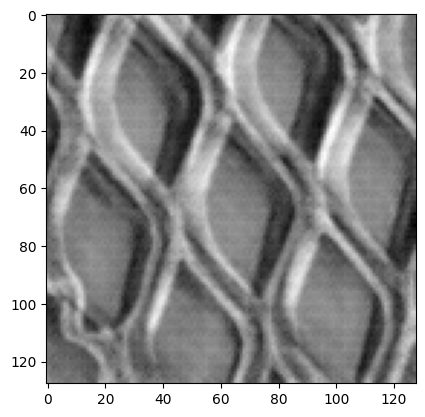

In [ ]:
difference_image_classical=((gen_image_classical-real_image))
plt.imshow((vutils.make_grid(difference_image_classical, padding=5, normalize=True).cpu()),cmap='gray')